# Nairobi Property Valuation Project

This notebook walks through the entire workflow: data generation, training an XGBoost model, visualizations, and making predictions.

## 1. Setup and Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import joblib

## 2. Data Generation / Loading

In [3]:
# the data can be generated using the logic from houses.py if the csv is missing
import os
if not os.path.exists('nairobi_houses.csv'):
    from houses import df as generated_df  # houses.py writes the file when imported
    generated_df.to_csv('nairobi_houses.csv', index=False)

# load the dataset
df = pd.read_csv('nairobi_houses.csv')
df.head()

,Location,Size_sqm,Bedrooms,Bathrooms,Gated_Community,Price
0,Kilimani,172,4,4,1,32811305
1,Westlands,758,4,4,1,134368336
2,Langata,132,3,3,1,31356534
3,Syokimau,168,2,2,1,19104840
4,Ruaka,94,3,2,1,16224755


## 3. Train Model

In [4]:
X = df[['Size_sqm', 'Bedrooms', 'Bathrooms', 'Gated_Community']]
y = np.log1p(df['Price'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = XGBRegressor(n_estimators=1000, learning_rate=0.05, max_depth=6, subsample=0.8, early_stopping_rounds=50)
model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
joblib.dump(model, 'house_model.pkl')
print('Model trained and saved to house_model.pkl')

Model trained and saved to house_model.pkl


## 4. Evaluation

R-Squared Score: 0.8321
Mean Absolute Error: KSh 19,527,587


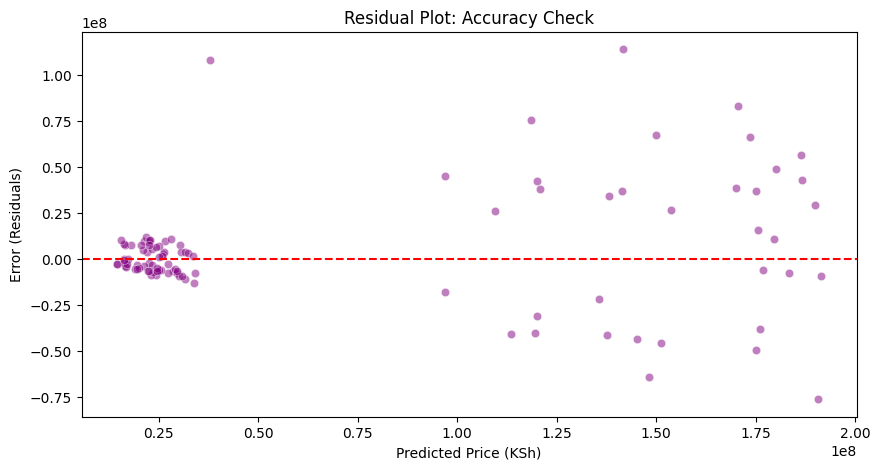

In [5]:
predictions = model.predict(X_test)
y_test_ksh = np.expm1(y_test)
pred_ksh = np.expm1(predictions)
print(f"R-Squared Score: {r2_score(y_test_ksh, pred_ksh):.4f}")
print(f"Mean Absolute Error: KSh {mean_absolute_error(y_test_ksh, pred_ksh):,.0f}")

# residual plot
residuals = y_test_ksh - pred_ksh
plt.figure(figsize=(10,5))
sns.scatterplot(x=pred_ksh, y=residuals, color='purple', alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residual Plot: Accuracy Check')
plt.xlabel('Predicted Price (KSh)')
plt.ylabel('Error (Residuals)')
plt.show()

## 5. Visualizations

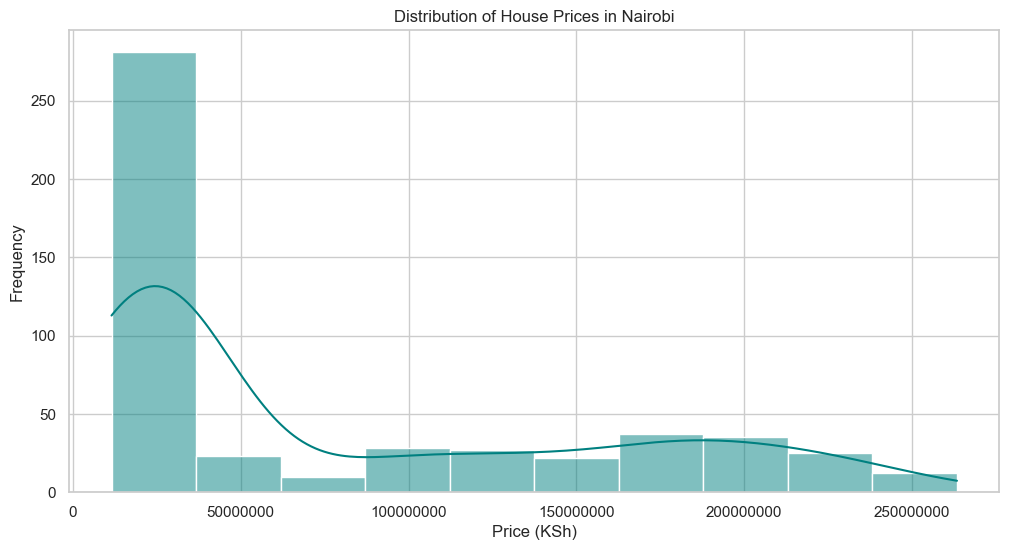

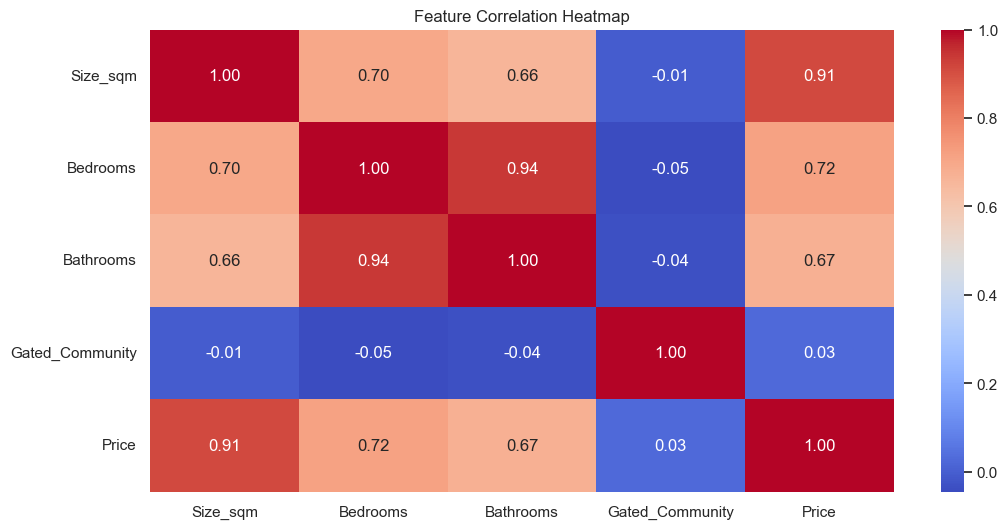

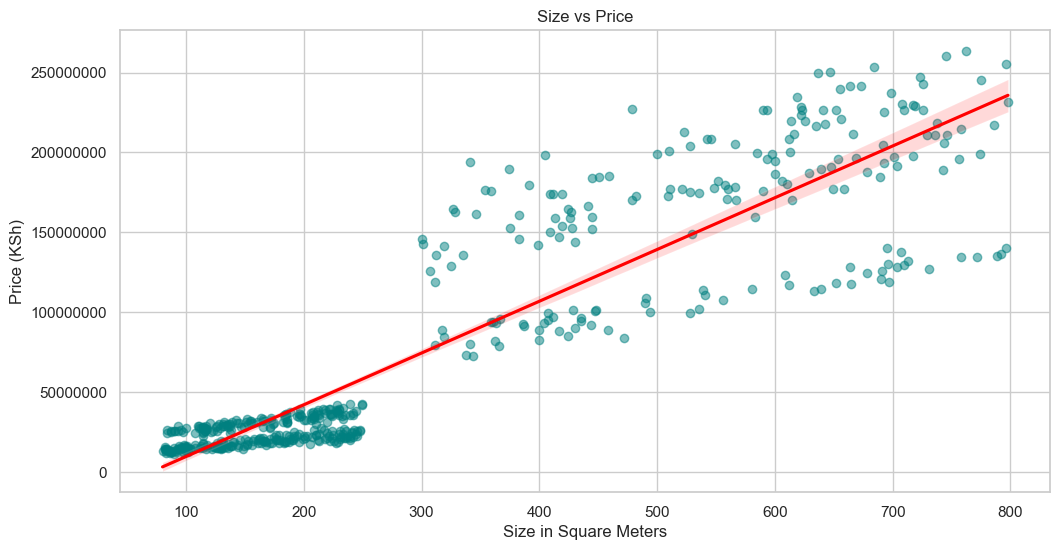

In [6]:
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12,6)

# price distribution
plt.figure()
sns.histplot(df['Price'], kde=True, color='teal')
plt.title('Distribution of House Prices in Nairobi')
plt.xlabel('Price (KSh)')
plt.ylabel('Frequency')
plt.ticklabel_format(style='plain', axis='x')
plt.show()

# correlation heatmap
plt.figure()
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.show()

# Size vs Price regression
plt.figure()
sns.regplot(x='Size_sqm', y='Price', data=df, scatter_kws={'alpha':0.5,'color':'teal'}, line_kws={'color':'red'})
plt.title('Size vs Price')
plt.xlabel('Size in Square Meters')
plt.ylabel('Price (KSh)')
plt.ticklabel_format(style='plain', axis='y')
plt.show()

## 6. Prediction Demo

In [7]:
# load saved model and make a sample prediction
m = joblib.load('house_model.pkl')
sample = pd.DataFrame([[150, 3, 2, 1]], columns=['Size_sqm','Bedrooms','Bathrooms','Gated_Community'])
log_pred = m.predict(sample)[0]
price = np.expm1(log_pred)
print(f"Predicted price for sample: KSh {price:,.0f}")

Predicted price for sample: KSh 24,097,248
